In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import pysam
from dimelo import parse_bam, plot_enrichment_profile, plot_reads, load_processed, plot_enrichment, export, plot_read_browser, plot_depth_profile

import config, plotting

In [2]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"
top_ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_motif_intersect_chip.top3k.bed"
ctcf_on_target_bed_file = config.processed_data_dir / "gm12878_ctcf.on_target.bed"
ctcf_off_target_bed_file = config.processed_data_dir / "gm12878_ctcf.off_target.bed"
ctcf_output_id = f"{ctcf_bam_file.stem}.{top_ctcf_bed_file.stem}"
# TODO: This file name will likely change; also should this pileup be performed elsewhere?
fiberseq_bam_file = config.processed_data_dir / "GM12878_WGS.retagged.bam"

ctcf_main_figure_window_size = 1000
# NOTE: Match window sizes set in third_party_data.ipynb
ctcf_on_target_window_size = 200
ctcf_off_target_window_size = 1300

# single read browser settings
ctcf_h1_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.h1.new.bam"
ctcf_h2_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.h2.new.bam"
ctcf_peak_bed_gz_file = config.processed_data_dir / "ENCFF797SDL.t2t_chm13v2.sorted.bed.gz"
gm12878_vcf = config.processed_data_dir / "NA12878.chm13v2.vcf.gz"
parse_regions = ["chrX:129_000_000-131_000_000","chrX:37_600_000-37_800_000"]
chrX_full = "chrX:0-248_956_422"
single_read_plot_center = 130_072_000
single_read_plot_window_size = 8000
single_read_plot_maternal_state = "active"
single_read_plot_paternal_state = "inactive"
single_read_plot_palette = {
    "A,0": "#1F77B4",
    "GCH,1": "#2CA02C",
    "WCG,1": "#D62728",
}
single_read_plot_colorscales = {k: ["white", v] for k, v in single_read_plot_palette.items()}

motifs = ["A,0", "GCH,1", "WCG,1"]
mod_prob_thresh = 0.95
smoothing = 25
n_cores = 10

Pileup/extract operations for on-/off-target regions

In [ ]:
parse_bam.pileup(
    input_file=ctcf_bam_file,
    output_name=f"pileup.{ctcf_output_id}",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=top_ctcf_bed_file,
    motifs=motifs,
    thresh=mod_prob_thresh,
    window_size=ctcf_on_target_window_size + ctcf_off_target_window_size,
    cores=n_cores,
    override_checks=True
)

parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=top_ctcf_bed_file,
    motifs=motifs,
    thresh=None, # No thresholding at extract time
    window_size=ctcf_main_figure_window_size,
    cores=n_cores,
    override_checks=True,
)

parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}.on_target",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=ctcf_on_target_bed_file,
    motifs=motifs,
    thresh=None, # No thresholding at extract time
    window_size=None,
    cores=n_cores,
    override_checks=True,
)

parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}.off_target",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=ctcf_off_target_bed_file,
    motifs=motifs,
    thresh=None, # No thresholding at extract time
    window_size=None,
    cores=n_cores,
    override_checks=True,
)

Export operations for genome browser

In [ ]:
# For now, chosing to export chr11 due to the presence of known CTCF features (β-globin, H19–Igf2)
export_region = "chr11:0-135127769"

output_name = f"pileup.{ctcf_bam_file.stem}.browser"
parse_bam.pileup(
    input_file=ctcf_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=motifs,
    thresh=mod_prob_thresh,
    cores=n_cores,
    override_checks=True
)

for motif in motifs:
    export.pileup_to_bigwig(
        bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
        motif=motif,
        bigwig_file=config.processed_data_dir / f"{output_name}_{motif.split(',')[0]}.bigWig",
        ref_genome=reference_file
    )


output_name = f"pileup.{fiberseq_bam_file.stem}.browser"
parse_bam.pileup(
    input_file=fiberseq_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=["A,0"],
    thresh=250,
    cores=n_cores,
    override_checks=True
)

export.pileup_to_bigwig(
    bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
    motif="A,0",
    bigwig_file=config.processed_data_dir / f"{output_name}_A.bigWig",
    ref_genome=reference_file
)

parse_bam.pileup(
    input_file=fiberseq_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=["CG,0"],
    thresh=0.5,
    cores=n_cores,
    override_checks=True
)

export.pileup_to_bigwig(
    bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
    motif="CG,0",
    bigwig_file=config.processed_data_dir / f"{output_name}_CG.bigWig",
    ref_genome=reference_file
)

Pileup and extract operations for haplotype phased single read plot

In [ ]:
parse_bam.extract(
    input_file=ctcf_h1_bam_file,
    output_name="hp1_chrX_extract",
    output_directory=config.processed_data_dir,
    ref_genome=reference_file,
    regions=parse_regions,
    motifs=motifs,
)
parse_bam.extract(
    input_file=ctcf_h2_bam_file,
    output_name="hp2_chrX_extract",
    output_directory=config.processed_data_dir,
    ref_genome=reference_file,
    regions=parse_regions,
    motifs=motifs,
    override_checks=True,
)
parse_bam.pileup(
    input_file=ctcf_h1_bam_file,
    output_name="hp1_chrX_pileup",
    output_directory=config.processed_data_dir,
    ref_genome=reference_file,
    regions=parse_regions,
    motifs=motifs,
    thresh=mod_prob_thresh,
)
parse_bam.pileup(
    input_file=ctcf_h2_bam_file,
    output_name="hp2_chrX_pileup",
    output_directory=config.processed_data_dir,
    ref_genome=reference_file,
    regions=parse_regions,
    motifs=motifs,
    thresh=mod_prob_thresh,
    override_checks=True,
)

# Main text figures

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

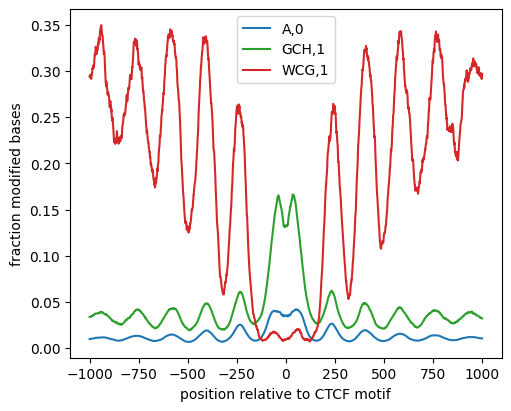

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(5, 4), layout="constrained")
plot_enrichment_profile.by_modification(
    config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
    regions=top_ctcf_bed_file,
    motifs=motifs,
    window_size=ctcf_main_figure_window_size,
    smooth_window=smoothing,
    palette=plotting.default_palette_map,
    ax=ax
)
ax.set_xlabel("position relative to CTCF motif")
ax.legend(title="")

plt.savefig(config.figure_dir / "ctcf.plot_enrichment_profile.svg")
plt.show()
plt.close()

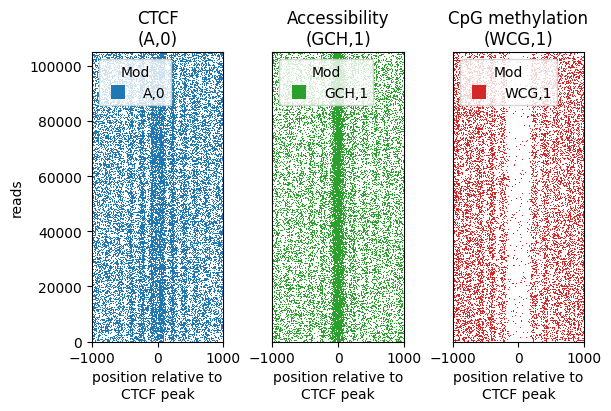

In [ ]:
_, axs = plt.subplots(1, 3, figsize=(6, 4), layout="constrained")
titles = ["CTCF", "Accessibility", "CpG methylation"]
for motif, ax, title in zip(motifs, axs, titles):
    plot_reads.plot_reads(
        mod_file_name=config.processed_data_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
        regions=top_ctcf_bed_file,
        motifs=motif,
        window_size=ctcf_main_figure_window_size,
        regions_5to3prime=False,
        sort_by="shuffle",
        thresh=mod_prob_thresh,
        ax=ax,
        palette=plotting.default_palette_map,
        rasterized=True,
        s=0.03
    )
    ax.set_title(f"{title}\n({motif})")
    ax.set_xlabel("position relative to\nCTCF peak")
    ax.set_ylabel("reads")
    if title != "CTCF":
        ax.yaxis.set_visible(False)
    ax.set_ylim(0,105000)
    sns.move_legend(ax, loc="upper left")

plt.savefig(config.figure_dir / "ctcf.plot_reads.svg")
plt.show()
plt.close()

## Single reads

In [3]:
def plot_genomic_region(variants, peaks, start_pos, end_pos, 
                        chromosome="chrX", 
                        variant_label="Variant sites",
                        peak_label="CTCF ChIP peaks",
                        figsize=(10, 2)):
    """
    Plot genomic regions with variants and peaks.
    
    Parameters:
    -----------
    variants : list of int
        List of positions for variants (shown as markers)
    peaks : list of tuples
        List of (start, end) positions for ChIP-seq peaks (large squares)
    start_pos : int
        Start position of the region (for left label)
    end_pos : int
        End position of the region (for right label)
    chromosome : str
        Chromosome name to display
    variant_label : str
        Label for the variants in legend
    peak_label : str
        Label for the peaks in legend
    figsize : tuple
        Figure size (width, height)
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw peaks (large squares) - draw first so variants appear on top
    peak_height = 0.2
    peak_y = 0.7
    for peak_start, peak_end in peaks:
        width = peak_end - peak_start
        rect = patches.Rectangle((peak_start, peak_y), width, peak_height,
                                 linewidth=0, facecolor='#1F77B4', zorder=3,
                                 label=peak_label if peak_start == peaks[0][0] else "")
        ax.add_patch(rect)
    
    # Draw variants as markers (small squares at specific positions)
    variant_y = 1.1
    for i, variant_pos in enumerate(variants):
        ax.plot(variant_pos, variant_y, 's', color='purple', 
                markersize=4, zorder=4,
                label=variant_label if i == 0 else "")
    
    # Set axis limits
    ax.set_xlim(start_pos, end_pos)
    ax.set_ylim(0, 1.2)
    
    # Configure x-axis with standard ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1)
    ax.set_yticks([])
    
    # Format x-axis ticks in Mbp
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}'))
    ax.set_xlabel(chromosome + " position", fontsize=11)
    ax.tick_params(axis='x', labelsize=10)
    # ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    # ax.spines['bottom'].set_visible(False)
    # ax.spines['top'].set_visible(True)
    
    # Add legend
    ax.legend(loc='lower right', frameon=False, fontsize=10)
    
    plt.tight_layout()
    return fig, ax

In [4]:
"""
Current pipeline for generating the bed file below:
sort -k 1,1 -k2,2n ENCFF797SDL.t2t_chm13v2.bed > ENCFF797SDL.t2t_chm13v2.sorted.bed
bgzip ENCFF797SDL.t2t_chm13v2.sorted.bed
tabix -p bed ENCFF797SDL.t2t_chm13v2.sorted.bed.gz
"""
peaks_tabix = pysam.TabixFile(str(ctcf_peak_bed_gz_file))
variants_tabix = pysam.TabixFile(str(gm12878_vcf))

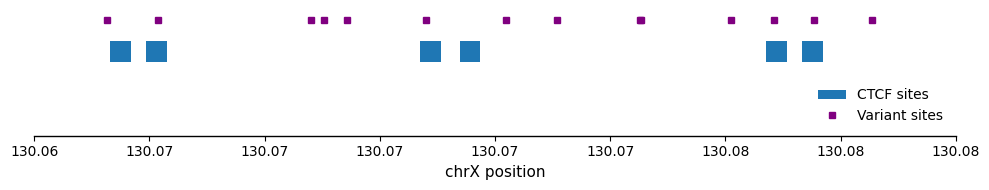

In [5]:
peaks_list = []
for peak_line in peaks_tabix.fetch("chrX", single_read_plot_center-single_read_plot_window_size, single_read_plot_center+single_read_plot_window_size):
    peak_fields = peak_line.strip().split('\t')
    peak_start = int(peak_fields[1])
    peak_end = int(peak_fields[2])
    peaks_list.append((peak_start, peak_end))
variant_pos_list = []
for variant_line in variants_tabix.fetch("chrX", single_read_plot_center-single_read_plot_window_size, single_read_plot_center+single_read_plot_window_size):
    variant_fields = variant_line.strip().split('\t')
    variant_pos = int(variant_fields[1])
    variant_pos_list.append(variant_pos)
fig, ax = plot_genomic_region(
    variants=variant_pos_list,
    peaks=peaks_list,
    start_pos=single_read_plot_center - single_read_plot_window_size,
    end_pos=single_read_plot_center + single_read_plot_window_size,
    chromosome="chrX",
    variant_label="Variant sites",
    peak_label="CTCF sites",
    figsize=(10, 2)
)
fig.savefig(config.figure_dir / f"chrX_{single_read_plot_center}.svg", format="svg", bbox_inches='tight', dpi=300)

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

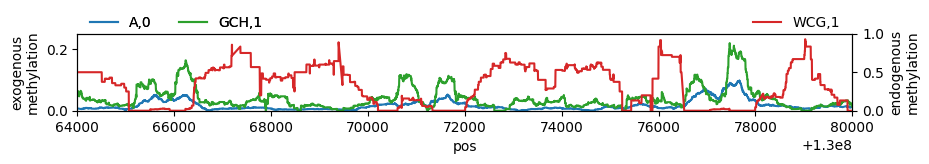

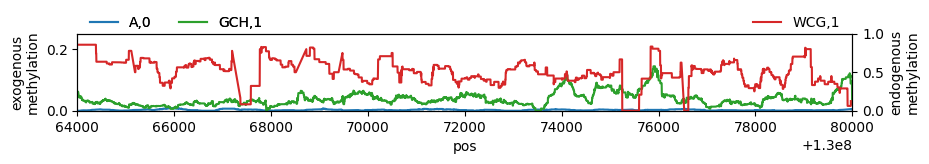

In [6]:
hp1_fig, hp1_ax1 = plt.subplots(figsize=(10,1))
hp2_fig, hp2_ax1 = plt.subplots(figsize=(10,1))
hp1_ax2 = hp1_ax1.twinx()
hp2_ax2 = hp2_ax1.twinx()
hp1_ax1.set_xlim(single_read_plot_center - single_read_plot_window_size, single_read_plot_center + single_read_plot_window_size)
hp2_ax1.set_xlim(single_read_plot_center - single_read_plot_window_size, single_read_plot_center + single_read_plot_window_size)
for profile_motifs, ylim, hp1_ax, hp2_ax in (
    (["A,0","GCH,1"], (0,0.25), hp1_ax1, hp2_ax1),
    (["WCG,1"], (0,1.0), hp1_ax2, hp2_ax2),
):
    smooth_window = 400
    plot_enrichment_profile.by_modification(
        mod_file_name=config.processed_data_dir / "hp1_chrX_pileup" / "pileup.sorted.bed.gz",
        regions = f"chrX:{single_read_plot_center - single_read_plot_window_size // 2}-{single_read_plot_center + single_read_plot_window_size // 2}",
        motifs=profile_motifs,
        window_size=single_read_plot_window_size,
        relative=False,
        smooth_window=smooth_window,
        palette=single_read_plot_palette,
        ax=hp1_ax,
    )
    hp1_ax.set_ylim(*ylim)
    hp1_ax.legend().remove()
    plot_enrichment_profile.by_modification(
        mod_file_name=config.processed_data_dir / "hp2_chrX_pileup" / "pileup.sorted.bed.gz",
        regions=f"chrX:{single_read_plot_center - single_read_plot_window_size // 2}-{single_read_plot_center + single_read_plot_window_size // 2}",
        motifs=profile_motifs,
        window_size=single_read_plot_window_size,
        relative=False,
        smooth_window=smooth_window,
        palette=single_read_plot_palette,
        ax=hp2_ax,
    )
    hp2_ax.set_ylim(*ylim)
    hp2_ax.legend().remove()
hp1_ax1.set_ylabel("exogenous\nmethylation")
hp1_ax2.set_ylabel("endogenous\nmethylation")
hp2_ax1.set_ylabel("exogenous\nmethylation")
hp2_ax2.set_ylabel("endogenous\nmethylation")

# Get handles and labels from both axes
handles1, labels1 = hp1_ax1.get_legend_handles_labels()
handles2, labels2 = hp1_ax2.get_legend_handles_labels()
# Create left legend (A,0 and GCH,1)
leg_left = hp1_ax1.legend(
    handles1, labels1,
    loc='upper left',
    bbox_to_anchor=(0, 1.4),
    ncol=2,
    frameon=False
)
# Create right legend (WCG,1) and add back the left legend
leg_right = hp1_ax2.legend(
    handles2, labels2,
    loc='upper right',
    bbox_to_anchor=(1, 1.4),
    ncol=1,
    frameon=False
)
# Important: add the left legend back since creating the right one removes it
hp1_ax1.add_artist(leg_left)
# Same for the second subplot
handles1, labels1 = hp2_ax1.get_legend_handles_labels()
handles2, labels2 = hp2_ax2.get_legend_handles_labels()

leg_left2 = hp2_ax1.legend(
    handles1, labels1,
    loc='upper left',
    bbox_to_anchor=(0, 1.4),
    ncol=2,
    frameon=False
)
leg_right2 = hp2_ax2.legend(
    handles2, labels2,
    loc='upper right',
    bbox_to_anchor=(1, 1.4),
    ncol=1,
    frameon=False
)

hp2_ax1.add_artist(leg_left2)

hp1_fig.savefig(f"maternal_{single_read_plot_maternal_state}_chrX_{single_read_plot_center}_enrichment_profile_smooth{smooth_window}.new.svg", format="svg", bbox_inches='tight', dpi=300)
hp2_fig.savefig(f"paternal_{single_read_plot_paternal_state}_chrX_{single_read_plot_center}_enrichment_profile_smooth{smooth_window}.new.svg", format="svg", bbox_inches='tight', dpi=300)

In [7]:
plot_width = 800
# TODO: Does the order of these motifs matter, or can I just reference the top-level motif list?
browser_motifs = ["WCG,1","A,0","GCH,1"]
browser_title = "Hia5 CTCF + M.CviPI accessibility"

for extract_file, haplotype in [
    (config.processed_data_dir / "hp1_chrX_extract" / "reads.combined_basemods.h5", f" paternal ({single_read_plot_maternal_state} X)"),
    (config.processed_data_dir / "hp2_chrX_extract" / "reads.combined_basemods.h5", f" maternal ({single_read_plot_paternal_state} X)")
]:
    sort_by = "collapse"
    fig = plot_read_browser.plot_read_browser(
        mod_file_name = extract_file,
        region = f'chrX:{single_read_plot_center-single_read_plot_window_size}-{single_read_plot_center+single_read_plot_window_size}',
        motifs = browser_motifs,
        thresh = 0.95,
        sort_by = sort_by,
        colorscales = single_read_plot_colorscales
    )
    fig.update_layout(
        width=plot_width,# these values are in pixels
        height=300,    
        title={
            'text': browser_title + haplotype,
            'x': 0.5,
            'xanchor': 'center',
            'y': 0.75,  # Adjust the vertical position of the title
            'yanchor': 'top',
            'pad': {'b': 10} 
        },
        xaxis_title='chr1 coordinate, t2t v2.0',
        yaxis_title='reads',
        font=dict(color='black')
    )
    fig.write_image(f"{haplotype.strip().replace(' ','_')}_chrX_{single_read_plot_center}_read_browser_width{plot_width}px.new.svg", format="svg", scale=2)
    # display(fig)

RuntimeError: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome



# Supplemental Figures

In [6]:
rng = np.random.default_rng()
mod_event_sample_size = 200000  # subsetting mod events to save on time and memory

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

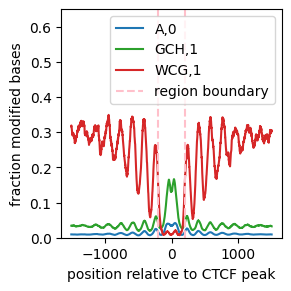

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(2.8, 2.8), layout="constrained")
ax = plot_enrichment_profile.by_modification(
    config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
    regions=top_ctcf_bed_file,
    motifs=motifs,
    window_size=ctcf_on_target_window_size + ctcf_off_target_window_size,
    smooth_window=smoothing,
    palette=plotting.default_palette_map
)
plt.axvline(-ctcf_on_target_window_size, linestyle="--", color="pink", label="region boundary")
plt.axvline(ctcf_on_target_window_size, linestyle="--", color="pink")
# recreate legend to both add new entry and restrict location to the bottom right quadrant
ax.set_ylim(0, 0.65)
ax.legend(
    loc='best',
    # bbox_to_anchor=(0.5, 0., 0.5, 0.5)
)
ax.set_xlabel("position relative to CTCF peak")
plt.savefig(config.figure_dir / "ctcf.plot_enrichment_profile.full.svg")
plt.show()
plt.close()

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

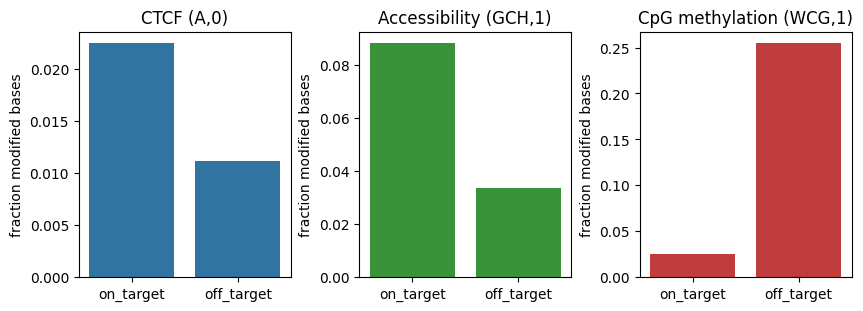

In [8]:
fig, axes = plt.subplots(1, 3, layout="constrained", figsize=(8.5, 3))

sample_names = ["on_target", "off_target"]
titles = ["CTCF", "Accessibility", "CpG methylation"]
for motif, ax, title in zip(motifs, axes, titles):
    plot_enrichment.by_regions(
        mod_file_name=config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
        regions_list=[ctcf_on_target_bed_file, ctcf_off_target_bed_file],
        motif=motif,
        sample_names=sample_names,
        palette = {sample_name: plotting.default_palette_map[motif] for sample_name in sample_names},
        ax=ax
    )
    ax.set_title(f"{title} ({motif})")

plt.savefig(config.figure_dir / "ctcf.plot_enrichment.svg")
plt.show()
plt.close()

In [9]:
on_target_motif_mod_vector_dict = {}
file_path = config.processed_data_dir / f"extract.{ctcf_output_id}.on_target" / "reads.combined_basemods.h5"
for motif in motifs:
    read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
        file=file_path,
        motifs=[motif],
        regions=ctcf_on_target_bed_file,
        single_strand=False,
        sort_by="shuffle",
        calculate_mod_fractions=False,
    )
    mod_vector_index = entry_labels.index("mod_vector")
    val_vector_index = entry_labels.index("val_vector")
    mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
    # TODO: Does it matter if I sample without replacement here?
    on_target_motif_mod_vector_dict[motif] = rng.choice(mod_vector, mod_event_sample_size, replace=False)

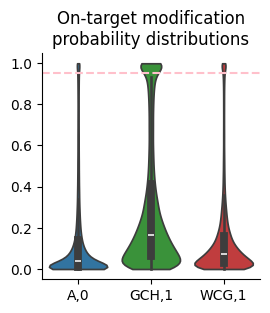

In [10]:
fig = sns.catplot(
    on_target_motif_mod_vector_dict, kind="violin", cut=0,
    palette=plotting.default_palette_map, height=2.8, aspect=1
)
plt.axhline(mod_prob_thresh, linestyle="--", color="pink")
plt.title("On-target modification\nprobability distributions")

plt.savefig(config.figure_dir / "ctcf.mod_probs.on_target.svg")
plt.show()
plt.close()

In [11]:
off_target_motif_mod_vector_dict = {}
file_path = config.processed_data_dir / f"extract.{ctcf_output_id}.off_target" / "reads.combined_basemods.h5"
for motif in motifs:
    read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
        file=file_path,
        motifs=[motif],
        regions=ctcf_off_target_bed_file,
        single_strand=False,
        sort_by="shuffle",
        calculate_mod_fractions=False,
    )
    mod_vector_index = entry_labels.index("mod_vector")
    val_vector_index = entry_labels.index("val_vector")
    mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
    # TODO: Does it matter if I sample without replacement here?
    off_target_motif_mod_vector_dict[motif] = rng.choice(mod_vector, mod_event_sample_size, replace=False)

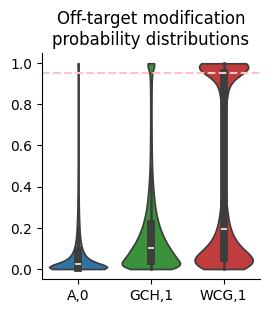

In [12]:
fig = sns.catplot(
    off_target_motif_mod_vector_dict, kind="violin", cut=0,
    palette=plotting.default_palette_map, height=2.8, aspect=1
)
plt.axhline(mod_prob_thresh, linestyle="--", color="pink")
plt.title("Off-target modification\nprobability distributions")

plt.savefig(config.figure_dir / "ctcf.mod_probs.off_target.svg")
plt.show()
plt.close()